---
jupyter:
  jupytext:
    text_representation:
      extension: .py
      format_name: light
      format_version: '1.5'
      jupytext_version: 1.17.2
  kernelspec:
    display_name: Python 3
    language: python
    name: python3
---

# BioDYM Material Flow Analysis - Scientific Notebook

A streamlined notebook for Material Flow Analysis using the BioDYM framework with enhanced plotting capabilities.

## Workflow Overview

This notebook follows a structured approach to Material Flow Analysis:

1. **Setup and Data Loading** - Prepare environment and load input data
2. **Calculation & Validation** - Execute MFA analysis and verify results
3. **Visualization** - Comprehensive analysis and exploration
4. **Export** - Save results and generate documentation

---

# 1. Setup and Data Loading

This section prepares the analysis environment and loads the input data.

## 1.1 Environment Setup

In [65]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML, Markdown

In [66]:
# Add BioDYM modules to path
src_path = os.path.join(os.getcwd(), 'src')
sys.path.insert(0, src_path)

In [67]:
# Add ODYM framework to path
biodym_mfa_tool_dir = os.getcwd()
odym_path = os.path.join(
    biodym_mfa_tool_dir, "framework", "ODYM-master_20241127", "odym", "modules"
)
sys.path.insert(0, odym_path)

In [68]:
# Add bioDYM add-on to path
biodym_addon_path = os.path.join(
    biodym_mfa_tool_dir, "framework", "bioDYM_add-on", "modules"
)
sys.path.insert(0, biodym_addon_path)

In [69]:
# Import BioDYM modules
try:
    import config
    import data_loader
    import system_setup
    import utils
    from engine import solver
    from src import plotting
    import ODYM_Classes as msc
    print("✅ BioDYM modules imported successfully")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("   Current Python path:")
    for i, path in enumerate(sys.path[:5]):  # Show first 5 paths
        print(f"   {i}: {path}")
    raise

✅ BioDYM modules imported successfully


In [70]:
# Set up plotting
plt.style.use('default')
print("📊 Plotting environment ready")

📊 Plotting environment ready


## 1.2 Data Input Configuration

**Change this variable to your Excel file:**

In [71]:
# Use the provided Excel file
input_file = "data/01_input/250902_CS1_Wheat_Straw.xlsx"

In [72]:
print(f"📁 Input file: {input_file}")

📁 Input file: data/01_input/250902_CS1_Wheat_Straw.xlsx


In [73]:
# Check if input file exists
if not os.path.exists(input_file):
    print(f"⚠️ Input file not found: {input_file}")
    print("   Please update the 'input_file' variable to point to your Excel file")
    print("   Example: input_file = 'path/to/your/data.xlsx'")
    raise FileNotFoundError(f"Input file not found: {input_file}")

## 1.3 Data Loading and Validation

In [74]:
print("\n" + "="*60)
print("[DATA] LOADING AND VALIDATING DATA")
print("="*60)


[DATA] LOADING AND VALIDATING DATA


In [75]:
# Load Excel file
try:
    input_data = pd.read_excel(
        input_file,
        sheet_name=None,
        header=0,
        engine='openpyxl',
        na_values=['N.A.', 'NA', 'n/a']
    )
    print(f"✅ Excel file loaded: {len(input_data)} sheets")
except Exception as e:
    print(f"❌ Error loading file: {e}")
    raise

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_

✅ Excel file loaded: 21 sheets


c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



In [76]:
# Display sheet overview
print("\n📋 Sheet Overview:")
for sheet_name, df in input_data.items():
    print(f"   {sheet_name}: {df.shape[0]} rows × {df.shape[1]} columns")


📋 Sheet Overview:
   Version_CS2_08.05.: 0 rows × 0 columns
   0_ReadMe: 73 rows × 20 columns
   Table of Content: 26 rows × 2 columns
   0_Configuration: 30 rows × 3 columns
   1_1_Definition_Flows: 78 rows × 22 columns
   1_2_Data_Flows: 349 rows × 37 columns
   2_1_Definition_Processes: 53 rows × 38 columns
   2_3_Process_TCs: 58 rows × 29 columns
   2_4_Initial_Stock: 62 rows × 21 columns
   2_5_dynamic_tcs: 148 rows × 64 columns
   3_1_Definition_DSM: 50 rows × 18 columns
   3_2_Definition_FOMP: 40 rows × 17 columns
   4_1_Uncertainty_Parameters: 20 rows × 10 columns
   5_1_Scenario_Manager: 12 rows × 7 columns
   3. TC_Data: 0 rows × 0 columns
   PX - Template: 71 rows × 23 columns
   4. Calculation_factors>>>>: 0 rows × 0 columns
   Sheet2: 15 rows × 5 columns
   4. Codelists>>>>: 0 rows × 1 columns
   4_1 Codelists: 95 rows × 23 columns
   5. Wastefiles >>>>: 0 rows × 1 columns


In [77]:
# Validate required sheets
required_sheets = [
    '1_1_Definition_Flows',
    '1_2_Data_Flows', 
    '2_1_Definition_Processes',
    '2_4_Initial_Stock',  # Correct sheet name
    '2_5_dynamic_tcs'
]

In [78]:
missing_sheets = [sheet for sheet in required_sheets if sheet not in input_data.keys()]
if missing_sheets:
    print(f"\n⚠️ Missing required sheets: {missing_sheets}")
else:
    print("\n✅ All required sheets present")


✅ All required sheets present


## 1.4 System Configuration Extraction

In [79]:
print("\n" + "="*60)
print("⚙️ EXTRACTING CONFIGURATION")
print("="*60)


⚙️ EXTRACTING CONFIGURATION


In [80]:
# Load configuration from Excel config sheet
try:
    config_dict = config.load_config_from_excel(input_file)
    print("✅ Configuration loaded from Excel config sheet")
    
    # Create proper config object for the solver
    config_obj = config.create_config_object(config_dict)
    print("✅ Configuration object created")
    
    # Use config values with fallbacks to data-driven values
    start_year = config_dict.get('Start Year', None)
    end_year = config_dict.get('End Year', None)
    elements_config = config_dict.get('Elements (comma-separated)', None)
    
    if elements_config:
        elements = elements_config.split(',')
    else:
        elements = ['material', 'WC', 'DM', 'CC']  # Default elements
    
    print(f"📅 Time range from config: {start_year} - {end_year}")
    print(f"🧪 Elements from config: {elements}")
    print(f"🎲 Monte Carlo: {'Enabled' if config_obj.RUN_MONTE_CARLO == True else 'Disabled'}")
    print(f"📊 DSM Calculation: {'Enabled' if config_obj.RUN_DSM_CALCULATION == True else 'Disabled'}")
    print(f"🌱 FOMP Calculation: {'Enabled' if config_obj.RUN_FOMP_CALCULATION == True else 'Disabled'}")
except Exception as e:
    print(f"⚠️ Could not load configuration: {e}")
    print("   Using data-driven configuration instead")
    
    # Fallback to data-driven configuration
    flow_data = input_data['1_2_Data_Flows']
    years = sorted(flow_data['Year_Flow'].unique())
    start_year = int(min(years))
    end_year = int(max(years))
    elements = ['material', 'WC', 'DM', 'CC']  # Default elements
    
    # Create default config object
    config_obj = config.get_default_config()
    
    print(f"📅 Time range from data: {start_year} - {end_year}")
    print(f"🧪 Elements from data: {elements}")
    print(f"🎲 Monte Carlo: {'Enabled' if config_obj.RUN_MONTE_CARLO == True else 'Disabled'}")
    print(f"📊 DSM Calculation: {'Enabled' if config_obj.RUN_DSM_CALCULATION == True else 'Disabled'}")
    print(f"🌱 FOMP Calculation: {'Enabled' if config_obj.RUN_FOMP_CALCULATION == True else 'Disabled'}")

✅ Found configuration sheet: '0_Configuration'
✅ Configuration loaded from Excel config sheet
✅ Configuration object created
📅 Time range from config: 2025 - 2050
🧪 Elements from config: ['material', 'WC', 'DM', 'CC']
🎲 Monte Carlo: Enabled
📊 DSM Calculation: Disabled
🌱 FOMP Calculation: Enabled


In [81]:
# Check for Monte Carlo parameters
has_mc = '4_1_Uncertainty_Parameters' in input_data.keys()
print(f"🎲 Monte Carlo available: {'Yes' if has_mc else 'No'}")

🎲 Monte Carlo available: Yes


In [82]:
# Check for DSM parameters
has_dsm = '3_1_Definition_DSM' in input_data.keys()
print(f"📈 DSM available: {'Yes' if has_dsm else 'No'}")

📈 DSM available: Yes


In [83]:
# Check for FOMP parameters
has_fomp = '3_2_Definition_FOMP' in input_data.keys()
print(f"🌱 FOMP available: {'Yes' if has_fomp else 'No'}")

🌱 FOMP available: Yes


## 1.5 Configuration Review

In [84]:
print("\n" + "="*60)
print("✅ CONFIGURATION CONFIRMATION")
print("="*60)


✅ CONFIGURATION CONFIRMATION


In [85]:
# Check if we loaded from config or fallback
config_source = "Excel Config Sheet" if 'config_dict' in locals() else "Data-Driven Fallback"

In [86]:
config_summary = f"""
**Analysis Configuration:**
- Input File: {input_file}
- Configuration Source: {config_source}
- Time Range: {start_year} - {end_year}
- Elements: {', '.join(elements)}
- Monte Carlo: {'Enabled' if has_mc else 'Disabled'}
- DSM: {'Enabled' if has_dsm else 'Disabled'}
- FOMP: {'Enabled' if has_fomp else 'Disabled'}

**Configuration Status:**
- ✅ Configuration integration active
- ✅ Excel config sheet now drives settings
- ✅ Fallback to data-driven values if needed
"""

In [87]:
display(Markdown(config_summary))


**Analysis Configuration:**
- Input File: data/01_input/250902_CS1_Wheat_Straw.xlsx
- Configuration Source: Excel Config Sheet
- Time Range: 2025 - 2050
- Elements: material, WC, DM, CC
- Monte Carlo: Enabled
- DSM: Enabled
- FOMP: Enabled

**Configuration Status:**
- ✅ Configuration integration active
- ✅ Excel config sheet now drives settings
- ✅ Fallback to data-driven values if needed


---
BioDYM Extension Notice
---

In [88]:
from IPython.display import display, Markdown

In [89]:
display(Markdown('''
**Note:** The stock-outflow transfer coefficient feature is a custom extension to the ODYM framework, developed specifically for BioDYM. It is not part of the standard ODYM release.
'''))


**Note:** The stock-outflow transfer coefficient feature is a custom extension to the ODYM framework, developed specifically for BioDYM. It is not part of the standard ODYM release.


# 2. Calculation & Validation

This section executes the MFA calculation and immediately validates the results through mass balance checks.

## 2.1 Model Initialization

In [90]:
print("\n" + "="*60)
print("🚀 RUNNING MFA CALCULATION")
print("="*60)


🚀 RUNNING MFA CALCULATION


In [91]:
# 1. Setup model scope
print("📋 Setting up model scope...")
try:
    model_classification, index_table = system_setup.define_model_scope(
        start_year, end_year, elements
    )
    print("✅ Model scope defined")
except Exception as e:
    print(f"❌ Error setting up model scope: {e}")
    raise

📋 Setting up model scope...
--> Model scope and classifications defined.
✅ Model scope defined


In [92]:
# 2. Initialize MFA system
print("🔧 Initializing MFA system...")
try:
    mfa_system_base = system_setup.initialize_mfa_system(
        model_classification, index_table
    )
    print("✅ MFA system initialized")
except Exception as e:
    print(f"❌ Error initializing MFA system: {e}")
    raise

🔧 Initializing MFA system...
--> MFA system object initialized.
✅ MFA system initialized


In [93]:
# 3. Load and define processes
print("📊 Loading processes and data...")
try:
    mfa_system_base, all_excel_data = system_setup.load_and_define_processes(
        mfa_system_base, input_file, data_loader
    )
    print("✅ Processes and data loaded")
except Exception as e:
    print(f"❌ Error loading processes: {e}")
    raise

📊 Loading processes and data...
--> Defining process and stock structures...


c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_

--> Validating input data structure...
--> Input data validation successful. All required sheets and columns are present.
--> Marked FOMP process 8 for zero stock initialization
--> Marked FOMP process 10 for zero stock initialization
--> Set FOMP process stock S_8 to zero BEFORE initialization
--> Set FOMP process stock S_10 to zero BEFORE initialization
--> Stock values initialized.
✅ Processes and data loaded


c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



In [94]:
# 4. Load parameters
print("⚙️ Loading parameters...")
try:
    dsm_params = data_loader.load_dsm_parameters(all_excel_data)
    
    # Check FOMP configuration before loading parameters
    if config_obj.RUN_FOMP_CALCULATION == True:
        fomp_params = data_loader.load_fomp_parameters(all_excel_data)
        print("✅ FOMP parameters loaded (FOMP enabled)")
    else:
        fomp_params = {}  # Empty FOMP parameters
        print("ℹ️ FOMP parameters skipped (FOMP disabled)")
    
    uncertainty_params = data_loader.load_uncertainty_definitions(all_excel_data)
    print("✅ Parameters loaded")
except Exception as e:
    print(f"❌ Error loading parameters: {e}")
    raise

⚙️ Loading parameters...
--> Loading DSM parameters from sheet '3_1_Definition_DSM'...
--> Successfully loaded configurations for 0 DSM process(es).
--> Loading FOMP parameters from sheet '3_2_Definition_FOMP'...
--> Loaded input flow composition: DM=0.86, CC=0.4128, WC=0.14
--> Successfully loaded configurations for 2 FOMP process(es).
   Process 8:
     Carbon outflow: F_08_00
     Environmental outflow: F_08_01
     Labile decay rate: 0.5
     Recalcitrant decay rate: 0.025
     Input composition: DM=0.860, CC=0.413, WC=0.140
   Process 10:
     Carbon outflow: F_10_00
     Labile decay rate: 0.05
     Recalcitrant decay rate: 0.0025
     Input composition: DM=0.860, CC=0.413, WC=0.140
✅ FOMP parameters loaded (FOMP enabled)
--> Loading uncertainty definitions from sheet '4_1_Uncertainty_Parameters'...
--> Successfully loaded 1 uncertainty parameter definition(s).
✅ Parameters loaded


## 2.2 MFA Calculation Execution

In [95]:
# 5. Define flows and parameters
print("🔗 Defining flows and parameters...")
try:
    mfa_system_configured, _ = system_setup.define_flows_and_parameters(
        mfa_system_base, all_excel_data
    )
    print(f"✅ System configured: {len(mfa_system_configured.ProcessList)} processes, "
          f"{len(mfa_system_configured.FlowDict)} flows, {len(mfa_system_configured.StockDict)} stocks")
except Exception as e:
    print(f"❌ Error defining flows and parameters: {e}")
    raise

🔗 Defining flows and parameters...
--> Defining flows, parameters, and setting all initial values...
--> All flows initialized to zero.
--> Populated data for primary input flows.
✅ System configured: 11 processes, 20 flows, 8 stocks


In [96]:
# 5.1 Process dynamic TCs
print("🔄 Processing dynamic transfer coefficients...")
try:
    dynamic_tc_sheet = all_excel_data.get('2_5_dynamic_tcs')
    if dynamic_tc_sheet is not None and not dynamic_tc_sheet.empty:
        dynamic_tcs = system_setup.create_dynamic_tc_parameters(
            dynamic_tc_sheet, mfa_system_configured.IndexTable.Classification['Time'].Items
        )
        # Add dynamic TCs to the system parameters
        for name, values in dynamic_tcs.items():
            mfa_system_configured.ParameterDict[name] = msc.Parameter(
                Name=name,
                ID=len(mfa_system_configured.ParameterDict) + 1,
                Values=values,
                Unit="1"
            )
        print(f"✅ Dynamic TCs processed: {len(dynamic_tcs)} parameters added")
    else:
        print("ℹ️ No dynamic TCs found in input data")
except Exception as e:
    print(f"⚠️ Warning: Could not process dynamic TCs: {e}")
    print("   Continuing with static TCs only")

🔄 Processing dynamic transfer coefficients...
--> Generating dynamic TC time series via interpolation...
--> Generated 3 dynamic TC parameter(s).
✅ Dynamic TCs processed: 3 parameters added


In [97]:
# 6. Run calculation
print("🧮 Running calculation...")
try:
    mfa_system_with_results, dsm_details = solver.run_mfa_calculation(
        mfa_system_configured, dsm_params, fomp_params, config_obj
    )
    print("✅ Calculation completed successfully!")
except Exception as e:
    print(f"❌ Calculation error: {e}")
    import traceback
    traceback.print_exc()
    raise

🧮 Running calculation...
   Total carbon output: 1584951.49
   Total environmental output: 1717030.78
    Protected FOMP output flow: F_08_00
    Protected FOMP output flow: F_08_01
   Total carbon output: 33790.94
   Total environmental output: 36606.85
    Protected FOMP output flow: F_10_00
    Protected FOMP output flow: F_10_01
--> Processing stock-outflow transfer coefficients...
--> No stock-outflow TCs found in system setup
--> Stock-outflow TC processing finished.
--> Calculating final stock balances for ALL processes...
--> Stock balance calculation finished.
✅ Calculation completed successfully!


## 2.3 Mass Balance Validation

In [98]:
print("\n" + "="*60)
print("⚖️ MASS BALANCE VERIFICATION")
print("="*60)


⚖️ MASS BALANCE VERIFICATION


In [99]:
# Calculate mass balance errors
mass_balance_errors = []
for process in mfa_system_with_results.ProcessList:
    if hasattr(process, 'MassBalance') and process.MassBalance is not None:
        for year_idx, year in enumerate(range(start_year, end_year + 1)):
            for element_idx, element in enumerate(elements):
                error = process.MassBalance[year_idx, element_idx]
                if abs(error) > 1e-6:  # Significant error threshold
                    mass_balance_errors.append({
                        'Process': process.Name,
                        'Year': year,
                        'Element': element,
                        'Error': error
                    })

In [100]:
if mass_balance_errors:
    print("⚠️ Mass balance errors detected:")
    error_df = pd.DataFrame(mass_balance_errors)
    display(error_df)
else:
    print("✅ All mass balances within acceptable limits")

✅ All mass balances within acceptable limits


In [101]:
# Mass Balance Error Visualization
print("\n⚖️ Creating mass balance error plots...")
try:
    # Display the general overview plot
    print("\n--- General Overview: Total Absolute Errors ---")
    
    # --- DEBUG CELL ---
    print("\n" + "="*30)
    print("🔬 DEBUGGING FLOW F_00_02")
    print("="*30)
    try:
        debug_flow = mfa_system_with_results.FlowDict.get('F_00_02')
        if debug_flow:
            print("Elements:", mfa_system_with_results.Elements)
            print("Flow F_00_02 Values (first 5 years):")
            print(pd.DataFrame(debug_flow.Values[:5, :], columns=mfa_system_with_results.Elements).to_string())
        else:
            print("Flow F_00_02 not found in the system.")
    except Exception as e:
        print(f"Error during debug: {e}")
    print("="*30)
    # --- END DEBUG CELL ---
    
    plotting.plot_total_mass_balance_error(mfa_system_with_results)
    
    # Display the time-specific interactive plot
    print("\n--- Time-Specific View: Interactive Error Check ---")
    plotting.plot_optimized_mass_balance_error(mfa_system_with_results)
    
    print("✅ Mass balance error plots created")
except Exception as e:
    print(f"⚠️ Could not create mass balance error plots: {e}")


⚖️ Creating mass balance error plots...

--- General Overview: Total Absolute Errors ---

🔬 DEBUGGING FLOW F_00_02
Elements: ['material', 'WC', 'DM', 'CC']
Flow F_00_02 Values (first 5 years):
    material   WC         DM         CC
0  297904.57  0.0  297904.57  297904.57
1  339142.51  0.0  339142.51  339142.51
2  257050.15  0.0  257050.15  257050.15
3  264047.97  0.0  264047.97  264047.97
4  344153.42  0.0  344153.42  344153.42



--- Time-Specific View: Interactive Error Check ---


interactive(children=(IntSlider(value=2025, description='Year', max=2050, min=2025), Dropdown(description='Ele…

FigureWidget({
    'data': [{'marker': {'color': [#7f7f7f, #7f7f7f, #7f7f7f, #7f7f7f, #7f7f7f,
                                   #d62728, #7f7f7f, #7f7f7f, #7f7f7f, #7f7f7f,
                                   #7f7f7f]},
              'type': 'bar',
              'uid': '8439df55-ec80-4abc-8c7f-8a9b2842f169',
              'x': [Atmosphere, Environment, Cultivation, Harvest, Grain
                    Processing & Consumption, Straw C&D, Direct Incorporation,
                    Animal bedding, Lithosphere (DI), Compostation & Incorporation,
                    Lithosphere (C&I)],
              'y': [0.0, 0.0, 0.0, 0.0, 0.0, 37959.73942999996, 0.0,
                    -1.4551915228366852e-11, 0.0, 0.0, 0.0]}],
    'layout': {'height': 500,
               'shapes': [{'line': {'color': 'black', 'width': 2},
                           'type': 'line',
                           'x0': -0.5,
                           'x1': 10.5,
                           'y0': 0,
                           

✅ Mass balance error plots created


In [102]:
# === Sankey-Style Block Flow Diagram ===
from src.plotting.graphviz_flow_charts import plot_graphviz_flow_chart_sankey_style
from IPython.display import Image, display
import tempfile
from datetime import datetime

In [103]:
print("\n" + "="*60)
print("🟦 SANKEY-STYLE BLOCK FLOW DIAGRAM")
print("="*60)


🟦 SANKEY-STYLE BLOCK FLOW DIAGRAM


c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



✅ Sankey-style block flow diagram created


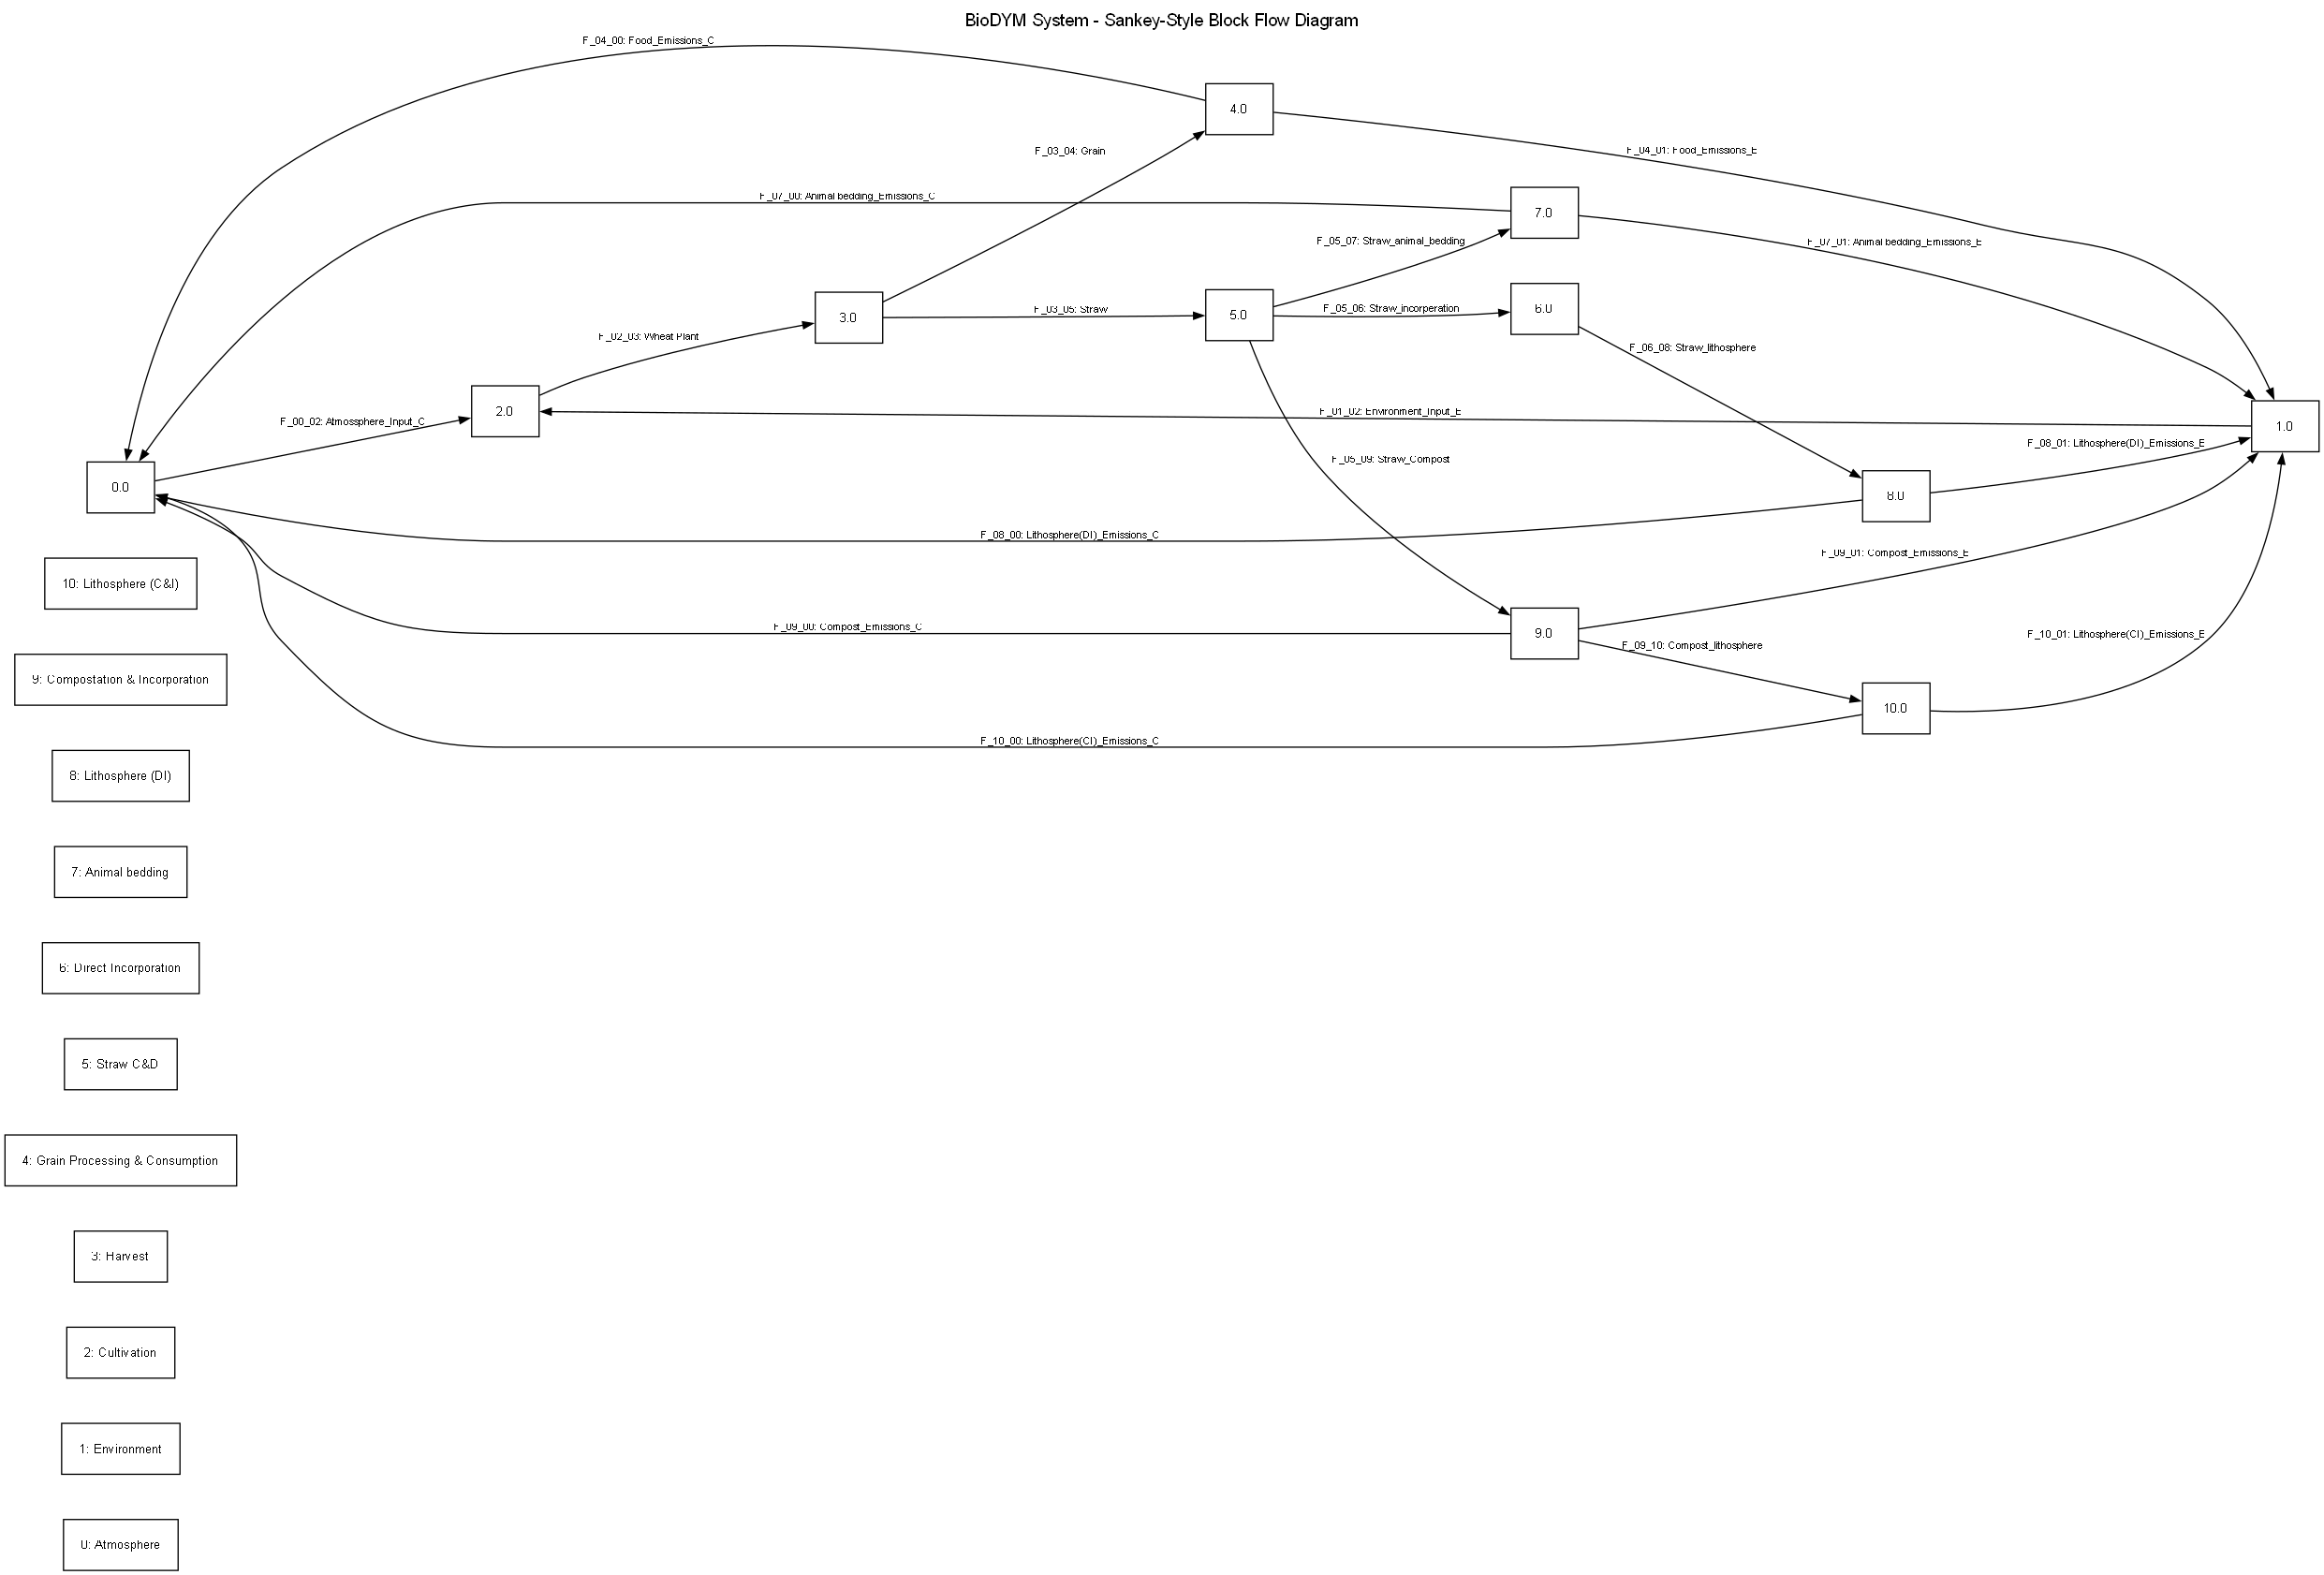

In [104]:
# Generate Sankey-Style Block Flow Diagram
try:
    dot_sankey = plot_graphviz_flow_chart_sankey_style(
        input_file,
        title="BioDYM System - Sankey-Style Block Flow Diagram",
        rankdir="LR",
        ranksep=1.0,
        nodesep=0.5
    )
    if dot_sankey is not None:
        # Create temporary file with better handling
        import os
        tmp_dir = tempfile.gettempdir()
        tmp_filename = f"biodym_sankey_style_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        tmp_path = os.path.join(tmp_dir, tmp_filename)
        
        # Render the diagram
        dot_sankey.render(tmp_path, format='png', cleanup=True)
        png_path = tmp_path + '.png'
        
        if os.path.exists(png_path):
            print("✅ Sankey-style block flow diagram created")
            display(Image(filename=png_path))
            # Clean up the file after display
            try:
                os.remove(png_path)
            except:
                pass  # Ignore cleanup errors
        else:
            print("❌ Failed to create PNG file")
    else:
        print("❌ Failed to create Sankey-style block flow diagram")
except Exception as e:
    print(f"❌ Error creating Sankey-style block flow diagram: {e}")

## 2.4 Results Overview

In [105]:
print("\n" + "="*60)
print("📈 RESULTS OVERVIEW")
print("="*60)


📈 RESULTS OVERVIEW


In [106]:
# Display final stock values
print("\n📊 Final Stock Values (Year {end_year}):")
final_stocks = []
for stock_name, stock in mfa_system_with_results.StockDict.items():
    if stock_name.startswith('S_'):  # Absolute stocks only
        final_value = stock.Values[-1, 0]  # Material dimension, final year
        final_stocks.append({
            'Stock': stock_name,
            'Final Value (Mg)': final_value
        })


📊 Final Stock Values (Year {end_year}):


In [107]:
if final_stocks:
    stocks_df = pd.DataFrame(final_stocks)
    display(stocks_df)

,Stock,Final Value (Mg)
0,S_0,-9.667545e+05
1,S_1,-7.306932e+05
2,S_8,1.424317e+06
3,S_10,7.600782e+05


In [108]:
# Display flow summary
print("\n🔄 Flow Summary:")
flow_summary = []
for flow_id, flow in mfa_system_with_results.FlowDict.items():
    avg_flow = np.mean(flow.Values[:, 0])  # Average material flow
    flow_summary.append({
        'Flow ID': flow_id,
        'From': flow.P_Start,
        'To': flow.P_End,
        'Avg Flow (Mg/year)': avg_flow
    })


🔄 Flow Summary:


In [109]:
if flow_summary:
    flows_df = pd.DataFrame(flow_summary)
    display(flows_df.head(10))  # Show first 10 flows

,Flow ID,From,To,Avg Flow (Mg/year)
0,F_00_02,0,2,334418.715769
1,F_01_02,1,2,475704.141923
2,F_02_03,2,3,810122.857692
3,F_03_04,3,4,383998.234546
4,F_03_05,3,5,426124.623146
5,F_04_00,4,0,158514.471221
6,F_04_01,4,1,225483.763326
7,F_05_06,5,6,213539.034059
8,F_06_08,6,8,213539.034059
9,F_05_07,5,7,106292.794543


# 3. Visualization

This section provides comprehensive analysis and exploration through various visualization tools.

In [110]:
print("\n" + "="*60)
print("📊 VISUALIZATION")
print("="*60)


📊 VISUALIZATION


## 3.1 System Overview

In [111]:
print("\n" + "-"*40)
print("3.1 SYSTEM OVERVIEW")
print("-"*40)


----------------------------------------
3.1 SYSTEM OVERVIEW
----------------------------------------


### 3.1.1 Material Flow Sankey Diagram

In [112]:
print("🔗 Creating interactive Sankey diagram...")
try:
    # Use the enhanced interactive Sankey function with DSM/FOMP parameters
    plotting.plot_interactive_sankey(mfa_system_with_results, dsm_params, fomp_params)
    print("✅ Interactive Sankey diagram created")
    print("   📊 Features: Multi-process selection, color coding, export options")
    print("   🎨 Process types: Regular (blue), DSM (orange), FOMP (green)")
    print("   📁 Export: PNG with timestamped filenames in organized folders")
except Exception as e:
    print(f"⚠️ Could not create interactive Sankey diagram: {e}")
    import traceback
    traceback.print_exc()

🔗 Creating interactive Sankey diagram...


FigureWidget({
    'data': [{'arrangement': 'snap',
              'link': {'color': [#1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4,
                                 #1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4,
                                 #1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4,
                                 #1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4],
                       'source': [0, 1, 2, 3, 3, 4, 4, 5, 6, 5, 7, 7, 8, 8, 5, 9,
                                  9, 10, 10, 9],
                       'target': [2, 2, 3, 4, 5, 0, 1, 6, 8, 7, 0, 1, 0, 1, 9, 0,
                                  1, 0, 1, 10],
                       'value': [297904.57, 423763.48, 721668.05, 342070.6557,
                                 379597.39430000004, 141206.76667296,
                                 200863.88902704, 151838.95772000003,
                                 151838.95772000003, 113879.21829, 47009.341310112,
                                 66869.87697988801, 0.0, 21257.45408080

✅ Interactive Sankey diagram created
   📊 Features: Multi-process selection, color coding, export options
   🎨 Process types: Regular (blue), DSM (orange), FOMP (green)
   📁 Export: PNG with timestamped filenames in organized folders


### 3.1.2 Process Dynamics Analysis

In [113]:
print("\n📊 Creating process dynamics analysis...")
try:
    # Use the process dynamics function for general process analysis
    if '2_1_Definition_Processes' in input_data:
        process_definitions = input_data['2_1_Definition_Processes']
        plotting.plot_process_dynamics(mfa_system_with_results, process_definitions)
        print("✅ Process dynamics analysis created")
        print("   📊 Features: Inflow, Stock, and Outflow for each process")
        print("   📈 Interactive: Process and element selection")
        print("   🎨 Smart titles based on process types")
    else:
        print("ℹ️ Process definitions not available for dynamics analysis")
except Exception as e:
    print(f"⚠️ Could not create process dynamics analysis: {e}")


📊 Creating process dynamics analysis...


interactive(children=(Dropdown(description='Process:', options=('Atmosphere', 'Environment', 'Cultivation', 'H…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Inflow',
              'type': 'scatter',
              'uid': '3852986f-b591-484c-ad0d-0d578d054392',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'xaxis': 'x',
              'y': array([207195.97769807, 253848.1146643 , 210716.32736731, 219661.15905372,
                          278958.53943814, 266695.99403536, 311633.78990382, 303372.79666497,
                          332261.25618028, 303816.98605891, 291323.90720754, 289490.92221179,
                          331629.28437171, 326637.38515737, 296262.77995463, 349906.4482116 ,
                          305656.53450188, 326759.19174511, 321285.63544313, 296406.2638752 ,
                          301198.9476931 , 323329.86784608, 331365.74365055, 289389.11648932,
                   

✅ Process dynamics analysis created
   📊 Features: Inflow, Stock, and Outflow for each process
   📈 Interactive: Process and element selection
   🎨 Smart titles based on process types


### 3.1.3 Stock Levels Bar Chart

In [114]:
print("\n📊 Creating stock levels bar chart...")
try:
    # Use the new stock bar chart function
    plotting.plot_stock_bar_chart(mfa_system_with_results, title="Stock Levels Over Time")
    print("✅ Stock levels bar chart created")
    print("   📊 Features: Interactive slider to view stocks per year")
    print("   🎨 Styling: Clear, publication-ready design")
except Exception as e:
    print(f"⚠️ Could not create stock levels bar chart: {e}")


📊 Creating stock levels bar chart...


interactive(children=(IntSlider(value=2025, description='Year', max=2050, min=2025), Dropdown(description='Ele…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Stock: %{y:.2f} Mg<extra></extra>',
              'marker': {'color': ['#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c']},
              'type': 'bar',
              'uid': 'ce4c74c8-0ad3-4388-a1bc-79f09ec8336b',
              'x': array(['Atmosphere', 'Environment', 'Lithosphere (DI)', 'Lithosphere (C&I)'],
                         dtype=object),
              'y': array([0., 0., 0., 0.])}],
    'layout': {'font': {'family': 'Arial, sans-serif', 'size': 12},
               'showlegend': False,
               'template': '...',
               'title': {'font': {'family': 'Arial, sans-serif', 'size': 20},
                         'text': 'Stock Levels Over Time - MATERIAL (2025)',
                         'x': 0.5},
               'xaxis': {'linecolor': 'black',
                         'linewidth': 1,
                         'showgrid': False,
                         'tickangle': -45,
                         'title': {'text': '

✅ Stock levels bar chart created
   📊 Features: Interactive slider to view stocks per year
   🎨 Styling: Clear, publication-ready design


## 3.2 Individual Process Analysis

In [115]:
print("\n" + "-"*40)
print("3.2 INDIVIDUAL PROCESS ANALYSIS")
print("-"*40)


----------------------------------------
3.2 INDIVIDUAL PROCESS ANALYSIS
----------------------------------------


### 3.2.1 DSM Process Analysis

In [116]:
print("\n📈 3.2.1 DSM Process Analysis:")
try:
    if has_dsm and dsm_details:
        plotting.plot_dsm_stock_details(mfa_system_with_results, dsm_params, dsm_details)
        print("✅ DSM process analysis plots created")
        print("   📊 Features: Individual/Cumulative views, lifetime display")
        print("   🎨 Enhanced styling with export functionality")
    else:
        print("ℹ️ No DSM processes available")
except Exception as e:
    print(f"⚠️ Could not create DSM process analysis: {e}")


📈 3.2.1 DSM Process Analysis:
ℹ️ No DSM processes available


### 3.2.2 DSM Stock Composition Analysis

In [117]:
print("\n📊 3.2.2 DSM Stock Composition Analysis:")
try:
    if has_dsm and dsm_details:
        plotting.plot_dynamic_stock_composition(dsm_details, mfa_system_with_results)
        print("✅ DSM stock composition analysis created")
        print("   📊 Features: Initial stock decay vs new stock accumulation")
        print("   📈 Options: Line charts or stacked bar charts")
        print("   🎨 Interactive: Process and element selection")
    else:
        print("ℹ️ No DSM processes available")
except Exception as e:
    print(f"⚠️ Could not create DSM stock composition analysis: {e}")


📊 3.2.2 DSM Stock Composition Analysis:
ℹ️ No DSM processes available


### 3.2.3 FOMP Process Analysis

In [118]:
print("\n🌱 3.2.3 FOMP Process Analysis:")
try:
    if has_fomp and fomp_params:
        plotting.plot_fomp_stock_details(mfa_system_with_results, fomp_params)
        print("✅ FOMP process analysis plots created")
    else:
        print("ℹ️ No FOMP processes available")
except Exception as e:
    print(f"⚠️ Could not create FOMP process analysis: {e}")


🌱 3.2.3 FOMP Process Analysis:


FigureWidget({
    'data': [{'hovertemplate': '<b>Stock</b><br>Year: %{x}<br>Mass: %{y:.2f} Mg<extra></extra>',
              'line': {'color': '#2ca02c', 'width': 3},
              'marker': {'size': 4},
              'mode': 'lines+markers',
              'name': 'Organic Matter Stock',
              'type': 'scatter',
              'uid': 'f03c9cc1-6a72-4d82-81ab-af7d46b6c2ca',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'y': array([      0.        ,  130581.5036392 ,  245279.02508656,  296815.34396856,
                           345780.65571226,  428226.1760179 ,  484009.75922444,  564745.39313255,
                           624415.15011213,  699140.44251777,  741780.64780383,  776819.69559213,
                           814596.15839081,  887442.17444782,  945080.23118215,  973900.69624894,
       

✅ FOMP process analysis plots created


## 3.3 Detailed Component Analysis

In [119]:
print("\n" + "-"*40)
print("3.3 DETAILED COMPONENT ANALYSIS")
print("-"*40)


----------------------------------------
3.3 DETAILED COMPONENT ANALYSIS
----------------------------------------


### 3.3.1 Individual Flow Analysis

In [120]:
print("\n🔄 Creating individual flow analysis...")
try:
    plotting.plot_flow_dynamics(mfa_system_with_results)
    print("✅ Individual flow analysis created")
    print("   📊 Features: Multi-flow selection, cumulative vs. individual values")
    print("   📈 Options: Bar/line charts, element-specific analysis")
except Exception as e:
    print(f"⚠️ Could not create individual flow analysis: {e}")


🔄 Creating individual flow analysis...
✅ Individual flow analysis created
   📊 Features: Multi-flow selection, cumulative vs. individual values
   📈 Options: Bar/line charts, element-specific analysis


Note: Additional flow chart visualizations removed - keeping only Sankey-style block flow diagram

# 4. Export

This section saves results and generates documentation for the analysis.

In [121]:
print("\n" + "="*60)
print("💾 EXPORTING RESULTS")
print("="*60)


💾 EXPORTING RESULTS


## 4.1 Results Export

In [122]:
# Export to Excel
output_file = "data/02_output/results_scientific.xlsx"
try:
    utils.export_results_to_excel(mfa_system_with_results, output_file)
    print(f"✅ Results exported to: {output_file}")
except Exception as e:
    print(f"⚠️ Export error: {e}")

--> Exporting results to 'data/02_output/results_scientific.xlsx'...
⚠️ Export error: [Errno 13] Permission denied: 'data/02_output/results_scientific.xlsx'


## 4.2 Configuration Export

In [123]:
# Export configuration summary
config_file = output_file.replace('.xlsx', '_config.xlsx')
try:
    config_summary = pd.DataFrame([{
        'Input File': input_file,
        'Start Year': start_year,
        'End Year': end_year,
        'Elements': ', '.join(elements),
        'Monte Carlo': has_mc,
        'DSM': has_dsm,
        'FOMP': has_fomp
    }])
    config_summary.to_excel(config_file, index=False)
    print(f"✅ Configuration exported to: {config_file}")
except Exception as e:
    print(f"⚠️ Config export error: {e}")

✅ Configuration exported to: data/02_output/results_scientific_config.xlsx


## 4.3 Analysis Summary

In [124]:
print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETE")
print("="*60)


🎉 ANALYSIS COMPLETE


In [125]:
summary = f"""
**Analysis Summary:**
- ✅ Input file processed successfully
- ✅ Configuration extracted automatically
- ✅ MFA calculation completed
- ✅ Mass balance verified
- ✅ Visualizations generated
- ✅ Results exported

**Key Results:**
- Time period: {start_year} - {end_year}
- Processes analyzed: {len(mfa_system_with_results.ProcessList)}
- Flows tracked: {len(mfa_system_with_results.FlowDict)}
- Stocks modeled: {len(mfa_system_with_results.StockDict)}
- Mass balance errors: {len(mass_balance_errors)}

**Files Generated:**
- Main results: {output_file}
- Configuration: {config_file}
"""

In [126]:
display(Markdown(summary))


**Analysis Summary:**
- ✅ Input file processed successfully
- ✅ Configuration extracted automatically
- ✅ MFA calculation completed
- ✅ Mass balance verified
- ✅ Visualizations generated
- ✅ Results exported

**Key Results:**
- Time period: 2025 - 2050
- Processes analyzed: 11
- Flows tracked: 20
- Stocks modeled: 8
- Mass balance errors: 0

**Files Generated:**
- Main results: data/02_output/results_scientific.xlsx
- Configuration: data/02_output/results_scientific_config.xlsx


In [127]:
print("\n📊 Analysis completed successfully!")


📊 Analysis completed successfully!


In [128]:
# Monte Carlo Analysis with proper error handling
try:
    from engine.mc_simulation import run_mc_simulation
    from plotting.mc_visuals import plot_interactive_mc_histogram, plot_interactive_tornado

    print("\n" + "="*60)
    print("🎲 MONTE CARLO SIMULATION")
    print("="*60)

    if has_mc:
        mc_results = run_mc_simulation(
            mfa_system_configured, input_data, dsm_params, fomp_params, config_obj
        )

        if mc_results is not None and not mc_results.empty:
            print("✅ Monte Carlo simulation completed")
            print("📊 Creating Monte Carlo stock histogram...")
            plot_interactive_mc_histogram(mc_results)
            stock_mc_cols = [col for col in mc_results.columns if col.endswith('_mc') and col.startswith('S_')]
            if stock_mc_cols:
                print("📈 Creating tornado plot for sensitivity analysis...")
                plot_interactive_tornado(mc_results)
            else:
                print("ℹ️ No stock columns found for tornado plot.")
        else:
            print("ℹ️ Monte Carlo simulation ran, but no results were generated. Check uncertainty definitions.")
    else:
        print("ℹ️ Monte Carlo analysis is disabled in the configuration. Skipping.")
except ImportError as e:
    print(f"⚠️ Monte Carlo modules not available: {e}")
except Exception as e:
    print(f"⚠️ Monte Carlo simulation failed: {e}")
    import traceback
    traceback.print_exc()


🎲 MONTE CARLO SIMULATION

[MC] Parameter Validation Warnings:
  ⚠️ WARNING: Process 3 has 2 outputs but only 0 TCs in MC. Missing: ['F_03_04', 'F_03_05']
  ⚠️ WARNING: Process 3 has 2 outputs but only 0 TCs in MC. Missing: ['F_03_04', 'F_03_05']


[MC] Running Monte Carlo simulation with 100 iterations...
[MC] Using 2 validated parameters...
  Running iteration 1/100...
   Total carbon output: 984053.76
   Total environmental output: 1066058.24
    Protected FOMP output flow: F_08_00
    Protected FOMP output flow: F_08_01
   Total carbon output: 20979.88
   Total environmental output: 22728.21
    Protected FOMP output flow: F_10_00
    Protected FOMP output flow: F_10_01
--> Processing stock-outflow transfer coefficients...
--> No stock-outflow TCs found in system setup
--> Stock-outflow TC processing finished.
--> Calculating final stock balances for ALL processes...
--> Stock balance calculation finished.
  Running iteration 2/100...
   Total carbon output: 1061021.16
   Total env

📈 Creating tornado plot for sensitivity analysis...
